# 🕵️ Testando Positivo (parte 3): variável aleatória discreta

Sabemos, desde a Aula 6, que cada funcionário tem 26% de chance de falhar no detector de mentiras. Agora vamos definir X = número de funcionários que falham, num grupo pequeno, como uma **variável aleatória discreta** — construindo a distribuição de probabilidade dela a partir da árvore de possibilidades, do jeito que vimos em aula (ainda sem usar a fórmula fechada da binomial, que só vem na Aula 9).

Só executar e ler, sem entrega.

## 1. Montando a árvore de possibilidades para 3 funcionários

Com 3 funcionários, cada um pode passar (P) ou falhar (F) no teste — existem 2³ = 8 combinações possíveis. Vamos listar todas elas e calcular a probabilidade de cada uma.

In [1]:
from itertools import product

p_falha = 0.26  # calculado na Aula 6 pela Probabilidade Total
p_passa = 1 - p_falha

resultados = []
for combinacao in product(["F", "P"], repeat=3):
    n_falhas = combinacao.count("F")
    probabilidade = 1.0
    for resultado in combinacao:
        probabilidade *= p_falha if resultado == "F" else p_passa
    resultados.append((combinacao, n_falhas, probabilidade))

print(f"{'Combinação':<12} {'X (nº falhas)':<15} {'Probabilidade'}")
for combinacao, n_falhas, probabilidade in resultados:
    print(f"{''.join(combinacao):<12} {n_falhas:<15} {probabilidade:.4f}")

Combinação   X (nº falhas)   Probabilidade
FFF          3               0.0176
FFP          2               0.0500
FPF          2               0.0500
FPP          1               0.1424
PFF          2               0.0500
PFP          1               0.1424
PPF          1               0.1424
PPP          0               0.4052


## 2. Construindo a distribuição de probabilidade de X

Várias combinações dão o mesmo valor de X (por exemplo, "FPP", "PFP" e "PPF" têm todas X=1). Vamos somar as probabilidades por valor de X.

In [2]:
import pandas as pd

tabela = pd.DataFrame(resultados, columns=["combinacao", "X", "probabilidade"])
distribuicao_X = tabela.groupby("X")["probabilidade"].sum()

print("Distribuição de probabilidade de X (número de funcionários que falham, entre 3):")
print(distribuicao_X)
print(f"\nSoma de todas as probabilidades: {distribuicao_X.sum():.4f} (tem que dar 1)")

Distribuição de probabilidade de X (número de funcionários que falham, entre 3):
X
0    0.405224
1    0.427128
2    0.150072
3    0.017576
Name: probabilidade, dtype: float64

Soma de todas as probabilidades: 1.0000 (tem que dar 1)


## 3. Valor esperado e variância de X

Agora, usando a definição — E[X] = soma de x · P(X=x) — calculamos o valor esperado e a variância.

In [3]:
valores_x = distribuicao_X.index.to_numpy()
probabilidades = distribuicao_X.to_numpy()

esperanca = (valores_x * probabilidades).sum()
variancia = ((valores_x - esperanca) ** 2 * probabilidades).sum()

print(f"E[X] = {esperanca:.4f}")
print(f"Var[X] = {variancia:.4f}")
print(f"\nCompare com o atalho 'intuitivo' n × p = 3 × {p_falha} = {3 * p_falha:.4f}")

E[X] = 0.7800
Var[X] = 0.5772

Compare com o atalho 'intuitivo' n × p = 3 × 0.26 = 0.7800


O atalho "n × p" bate exatamente com o E[X] calculado pela definição completa — isso não é coincidência, mas a demonstração formal de por que isso sempre funciona fica para quando virmos a distribuição Binomial, na Aula 9.

## 4. Conferindo por simulação

Vamos simular 500.000 grupos de 3 funcionários e comparar a distribuição empírica de X com a que calculamos pela árvore.

In [4]:
import numpy as np
rng = np.random.default_rng(7)

n_grupos = 500_000
falhas_por_grupo = rng.random((n_grupos, 3)) < p_falha
X_simulado = falhas_por_grupo.sum(axis=1)

distribuicao_simulada = pd.Series(X_simulado).value_counts(normalize=True).sort_index()

comparacao = pd.DataFrame({
    "Teórico": distribuicao_X,
    "Simulado": distribuicao_simulada,
})
comparacao

,Teórico,Simulado
0,0.405224,0.404946
1,0.427128,0.427210
2,0.150072,0.150558
3,0.017576,0.017286


## 5. E se o grupo fosse maior?

Só por curiosidade: vamos ver como a distribuição de X muda se o grupo tivesse 10 funcionários em vez de 3 (usando simulação, sem precisar listar 2¹⁰ = 1024 combinações à mão).

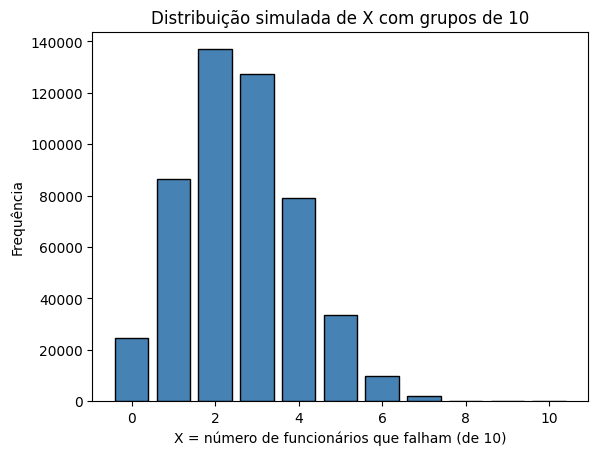

In [5]:
falhas_grupo_10 = rng.random((n_grupos, 10)) < p_falha
X_grupo_10 = falhas_grupo_10.sum(axis=1)

import matplotlib.pyplot as plt
plt.hist(X_grupo_10, bins=range(0, 12), align="left", rwidth=0.8, color="steelblue", edgecolor="black")
plt.xlabel("X = número de funcionários que falham (de 10)")
plt.ylabel("Frequência")
plt.title("Distribuição simulada de X com grupos de 10")
plt.show()

## Para fechar (por enquanto)

Construímos a distribuição de X inteira, a partir da árvore de possibilidades, sem usar nenhuma fórmula fechada — só contando. Na Aula 8 vamos reformular esse mesmo problema com uma medida **contínua**.